# 03 — Player Performance Factors
Which stats predict map wins, and does that differ between T1 and T2?


In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

from eda.utils import load_tables, enrich_matches, get_working_matches, get_completed_maps, savefig

tables = load_tables()
matches = enrich_matches(tables['matches'])
working = get_working_matches(matches)
comp_maps = get_completed_maps(tables['maps'], working)


In [2]:
# Build: map_player_stats joined with map winner
mps = tables['map_player_stats']
mps_j = mps.merge(comp_maps[['map_id','tier','map_winner_id','team1_id','team2_id']],
                  on='map_id', how='inner')
mps_j['won'] = (mps_j['team_id'] == mps_j['map_winner_id']).astype(int)
print(f"Player-map rows: {len(mps_j):,}")
print(f"Tiers: {mps_j['tier'].value_counts().to_dict()}")


Player-map rows: 439,201
Tiers: {'tier2': 188114, 'tier1': 174542, 'game_changers': 76545}


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/03_stat_distributions.png


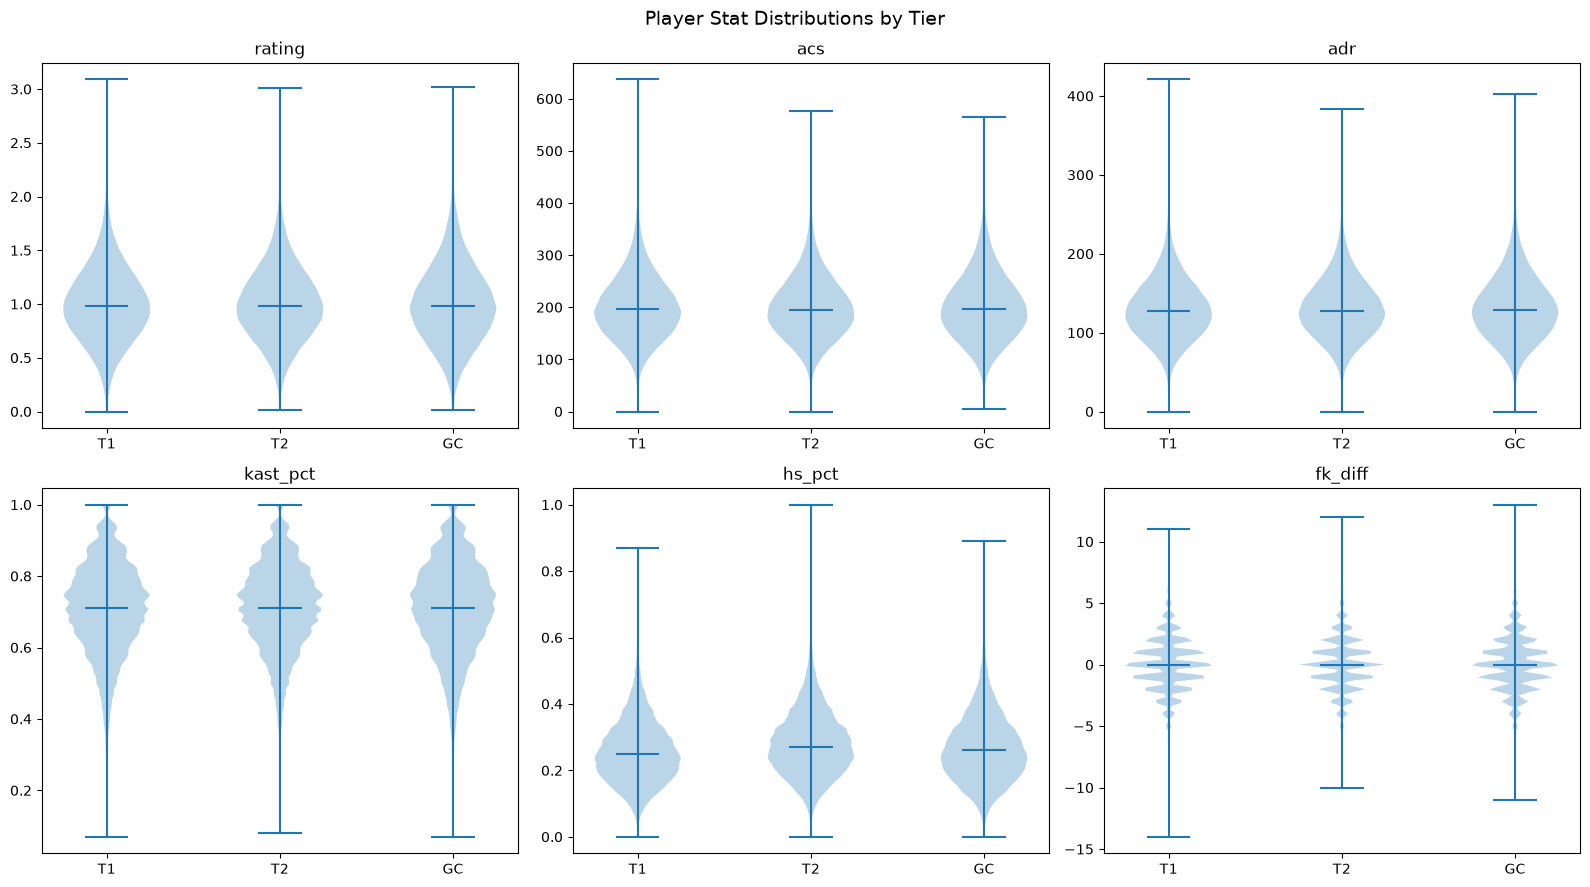

In [3]:
# 3a. Stat distributions by tier (violin plots)
STATS = ['rating','acs','adr','kast_pct','hs_pct','fk_diff']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, stat in zip(axes.flat, STATS):
    data = [mps_j[mps_j['tier']==t][stat].dropna() for t in ['tier1','tier2','game_changers']]
    ax.violinplot(data, positions=[1,2,3], showmedians=True)
    ax.set_xticks([1,2,3]); ax.set_xticklabels(['T1','T2','GC'])
    ax.set_title(stat)
fig.suptitle('Player Stat Distributions by Tier', fontsize=14)
plt.tight_layout()
savefig(fig, '03_stat_distributions')
plt.show()


In [4]:
# 3b. Aggregate to team level per map; correlate with win
team_stats = mps_j.groupby(['map_id','team_id','tier','won']).agg(
    mean_acs    = ('acs',      'mean'),
    mean_adr    = ('adr',      'mean'),
    mean_kast   = ('kast_pct', 'mean'),
    mean_rating = ('rating',   'mean'),
    total_fk_diff = ('fk_diff','sum'),
    total_kd_diff = ('kd_diff','sum'),
).reset_index()

corr_results = {}
for tier in ['tier1','tier2','game_changers']:
    sub = team_stats[team_stats['tier']==tier]
    corr = sub[['mean_acs','mean_adr','mean_kast','mean_rating',
                 'total_fk_diff','total_kd_diff','won']].corr()['won'].drop('won')
    corr_results[tier] = corr
print(pd.DataFrame(corr_results))


                  tier1     tier2  game_changers
mean_acs       0.721060  0.714307       0.733823
mean_adr       0.667170  0.679273       0.710359
mean_kast      0.698021  0.688015       0.707886
mean_rating    0.786690  0.791780       0.795657
total_fk_diff  0.518578  0.507942       0.551343
total_kd_diff  0.833054  0.831383       0.840393


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/03_fk_advantage.png


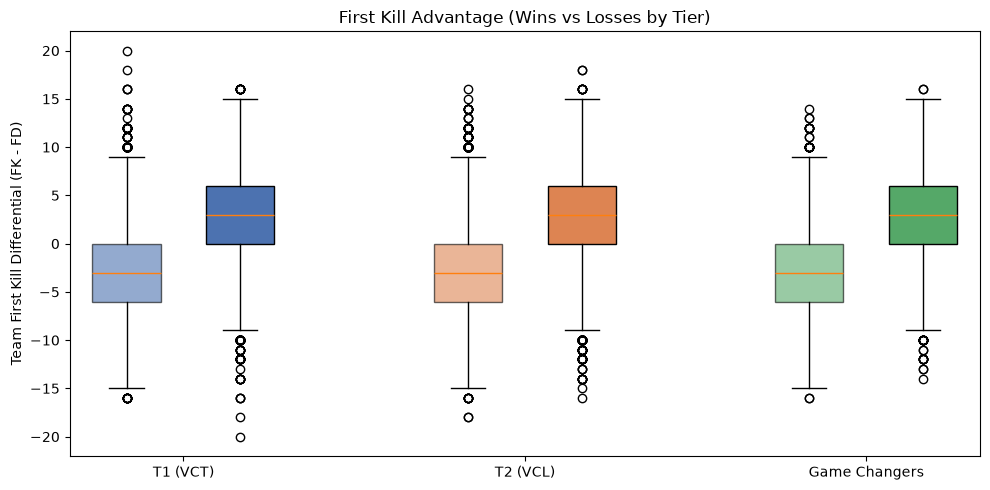

In [5]:
# 3c. First kill advantage
fk_team = mps_j.groupby(['map_id','team_id','tier','won']).agg(
    team_fk_diff=('fk_diff','sum')
).reset_index()

fig, ax = plt.subplots(figsize=(10,5))
colors = {'tier1': '#4C72B0', 'tier2': '#DD8452', 'game_changers': '#55A868'}
for i, tier in enumerate(['tier1','tier2','game_changers']):
    for j, outcome in enumerate([0, 1]):
        data = fk_team[(fk_team['tier']==tier) & (fk_team['won']==outcome)]['team_fk_diff'].dropna()
        pos = i*3 + j + 1
        ax.boxplot(data, positions=[pos], widths=0.6, patch_artist=True,
                   boxprops=dict(facecolor=colors[tier], alpha=0.6 if outcome==0 else 1.0))
ax.set_xticks([1.5, 4.5, 7.5])
ax.set_xticklabels(['T1 (VCT)', 'T2 (VCL)', 'Game Changers'])
ax.set_title('First Kill Advantage (Wins vs Losses by Tier)')
ax.set_ylabel('Team First Kill Differential (FK - FD)')
plt.tight_layout()
savefig(fig, '03_fk_advantage')
plt.show()


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/03_agent_meta.png


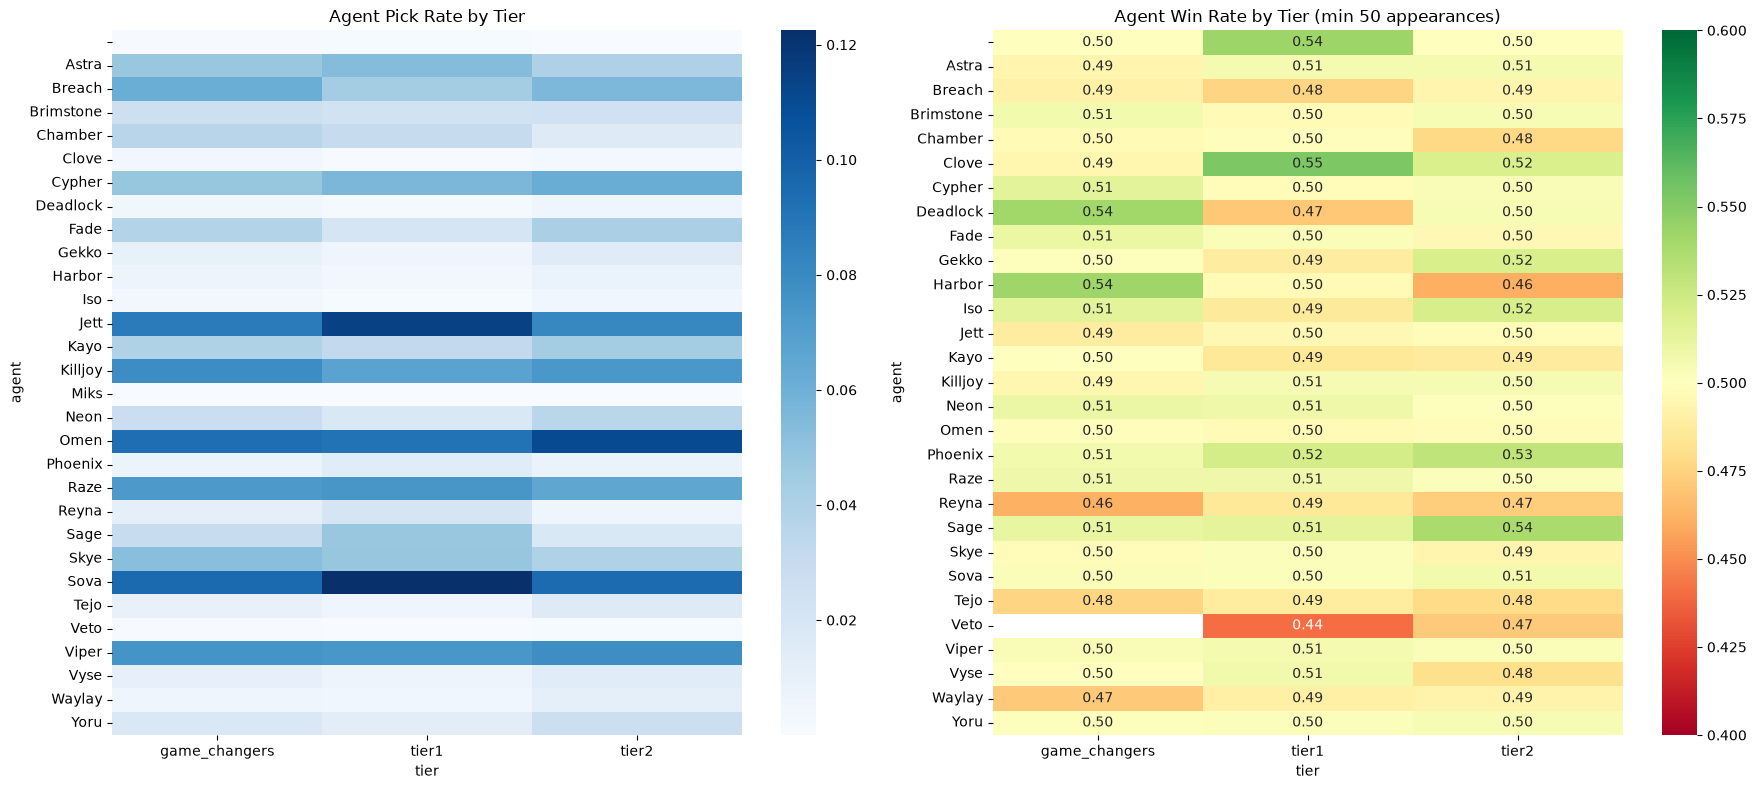

In [6]:
# 3d. Agent meta: pick rate and win rate
agent_picks = mps_j.groupby(['tier','agent']).size().unstack(fill_value=0)
agent_picks_norm = agent_picks.div(agent_picks.sum(axis=1), axis=0)

# Win rate per agent × tier (min 50 appearances)
agent_wr = mps_j.groupby(['tier','agent']).agg(
    appearances=('won','count'),
    wins=('won','sum')
).reset_index()
agent_wr['winrate'] = agent_wr['wins'] / agent_wr['appearances']
agent_wr = agent_wr[agent_wr['appearances'] >= 50]
agent_wr_pivot = agent_wr.pivot(index='agent', columns='tier', values='winrate')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(agent_picks_norm.T, ax=axes[0], cmap='Blues', annot=False)
axes[0].set_title('Agent Pick Rate by Tier')
sns.heatmap(agent_wr_pivot, ax=axes[1], cmap='RdYlGn', center=0.5,
            vmin=0.40, vmax=0.60, annot=True, fmt='.2f')
axes[1].set_title('Agent Win Rate by Tier (min 50 appearances)')
plt.tight_layout()
savefig(fig, '03_agent_meta')
plt.show()


In [7]:
# 3e. KAST threshold analysis
mps_j['kast_quartile'] = pd.qcut(mps_j['kast_pct'].dropna(), q=4,
                                   labels=['Q1 (low)','Q2','Q3','Q4 (high)'])
kast_wr = mps_j.groupby(['tier','kast_quartile'])['won'].mean().unstack()
print("Win rate by KAST quartile and tier:")
print(kast_wr.to_string())


Win rate by KAST quartile and tier:
kast_quartile  Q1 (low)        Q2        Q3  Q4 (high)
tier                                                  
game_changers  0.129548  0.407299  0.634170   0.866411
tier1          0.138702  0.412951  0.640378   0.862144
tier2          0.148951  0.408584  0.622774   0.845241


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/03_clutches_multifrags.png

/var/folders/d7/_v28fw1j0db59x5d9_8bxrmm0000gn/T/ipykernel_44850/270587103.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['2K', '3K', '4K', '5K (Ace)'])
/var/folders/d7/_v28fw1j0db59x5d9_8bxrmm0000gn/T/ipykernel_44850/270587103.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['1v1', '1v2', '1v3', '1v4', '1v5'])


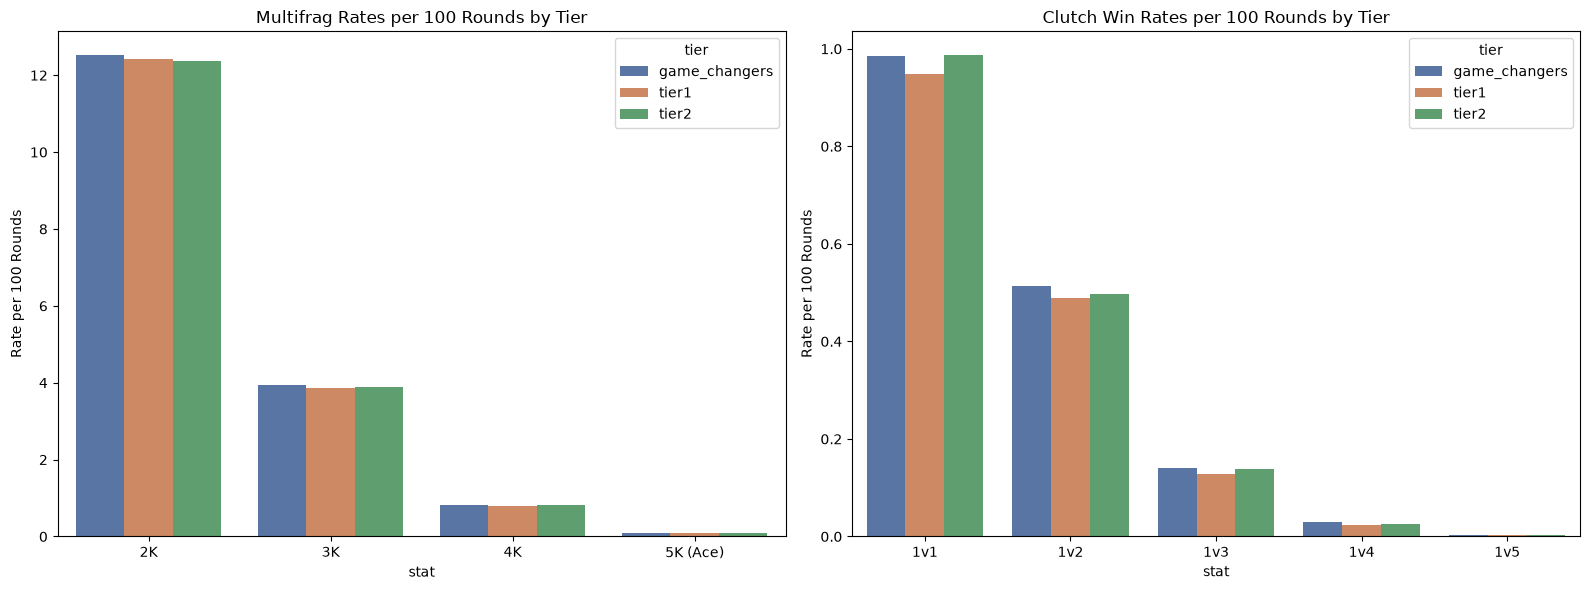

In [8]:
# 3f. Clutches and Multifrags (advanced stats comparison)
import seaborn as sns
from scipy.stats import mannwhitneyu

# Calculate total rounds per match to normalize
comp_maps['total_rounds'] = comp_maps['team1_score'].astype(float) + comp_maps['team2_score'].astype(float)
match_rounds = comp_maps.groupby('match_id')['total_rounds'].sum().reset_index()

adv = tables['series_advanced_stats']
adv_w = adv.merge(working[['match_id', 'tier']], on='match_id', how='inner')
adv_w = adv_w.merge(match_rounds, on='match_id', how='inner')

# Convert advanced stats columns to float, fill na with 0
cols = ['k2', 'k3', 'k4', 'k5', 'clutch_1v1', 'clutch_1v2', 'clutch_1v3', 'clutch_1v4', 'clutch_1v5']
for c in cols:
    adv_w[c] = pd.to_numeric(adv_w[c], errors='coerce').fillna(0)

# Filter out matches with 0 rounds
adv_w = adv_w[adv_w['total_rounds'] > 0].copy()

# Calculate rates per 100 rounds
rates_cols = []
for c in cols:
    col_name = f'{c}_rate'
    adv_w[col_name] = (adv_w[c] / adv_w['total_rounds']) * 100
    rates_cols.append(col_name)

# Mean rates by tier
mean_rates = adv_w.groupby('tier')[rates_cols].mean().reset_index()
melted = mean_rates.melt(id_vars='tier', var_name='stat', value_name='rate_per_100_rounds')

# Separate into clutches and multifrags for plotting
multifrag_stats = ['k2_rate', 'k3_rate', 'k4_rate', 'k5_rate']
clutch_stats = ['clutch_1v1_rate', 'clutch_1v2_rate', 'clutch_1v3_rate', 'clutch_1v4_rate', 'clutch_1v5_rate']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot multifrags
sns.barplot(
    data=melted[melted['stat'].isin(multifrag_stats)],
    x='stat', y='rate_per_100_rounds', hue='tier',
    ax=axes[0], palette=['#4C72B0', '#DD8452', '#55A868']
)
axes[0].set_title('Multifrag Rates per 100 Rounds by Tier')
axes[0].set_ylabel('Rate per 100 Rounds')
axes[0].set_xticklabels(['2K', '3K', '4K', '5K (Ace)'])

# Plot clutches
sns.barplot(
    data=melted[melted['stat'].isin(clutch_stats)],
    x='stat', y='rate_per_100_rounds', hue='tier',
    ax=axes[1], palette=['#4C72B0', '#DD8452', '#55A868']
)
axes[1].set_title('Clutch Win Rates per 100 Rounds by Tier')
axes[1].set_ylabel('Rate per 100 Rounds')
axes[1].set_xticklabels(['1v1', '1v2', '1v3', '1v4', '1v5'])

plt.tight_layout()
savefig(fig, '03_clutches_multifrags')
plt.show()


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/03_role_rating_distribution.png


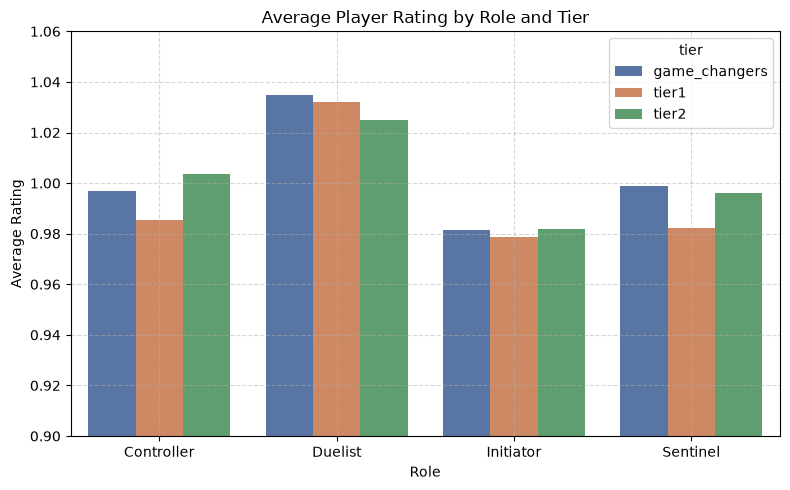

=== Role-Level Stats (T1 vs. T2 vs. GC) ===

DUELIST:
  Tier 1 Rating: 1.0319 (ACS: 229.4)
  Tier 2 Rating: 1.0248 (ACS: 227.0)
  Game Changers Rating: 1.0349 (ACS: 231.7)

INITIATOR:
  Tier 1 Rating: 0.9786 (ACS: 188.0)
  Tier 2 Rating: 0.9820 (ACS: 186.1)
  Game Changers Rating: 0.9813 (ACS: 186.9)

CONTROLLER:
  Tier 1 Rating: 0.9855 (ACS: 189.0)
  Tier 2 Rating: 1.0036 (ACS: 192.4)
  Game Changers Rating: 0.9969 (ACS: 192.3)

SENTINEL:
  Tier 1 Rating: 0.9822 (ACS: 195.7)
  Tier 2 Rating: 0.9962 (ACS: 196.3)
  Game Changers Rating: 0.9988 (ACS: 198.9)


In [9]:
# 3g. Player stats across roles and tiers
import seaborn as sns
from scipy.stats import ttest_ind

# Define the agent-to-role mapping
role_map = {
    'Jett': 'Duelist', 'Raze': 'Duelist', 'Reyna': 'Duelist', 'Phoenix': 'Duelist', 
    'Neon': 'Duelist', 'Yoru': 'Duelist', 'Iso': 'Duelist',
    'Sova': 'Initiator', 'Breach': 'Initiator', 'Skye': 'Initiator', 
    'Fade': 'Initiator', 'Gekko': 'Initiator', 'Kayo': 'Initiator',
    'Omen': 'Controller', 'Brimstone': 'Controller', 'Viper': 'Controller', 
    'Astra': 'Controller', 'Harbor': 'Controller', 'Clove': 'Controller',
    'Killjoy': 'Sentinel', 'Cypher': 'Sentinel', 'Sage': 'Sentinel', 
    'Chamber': 'Sentinel', 'Deadlock': 'Sentinel', 'Vyse': 'Sentinel'
}

mps_j['role'] = mps_j['agent'].map(role_map)
mps_role = mps_j.dropna(subset=['role']).copy()

# Ensure numeric types
for col in ['rating', 'acs', 'adr', 'kast_pct', 'fk_diff']:
    mps_role[col] = pd.to_numeric(mps_role[col], errors='coerce')
    
mps_role = mps_role.dropna(subset=['rating'])

# Calculate role summary
role_summary = mps_role.groupby(['role', 'tier']).agg(
    avg_rating=('rating', 'mean'),
    avg_acs=('acs', 'mean'),
    avg_adr=('adr', 'mean'),
    avg_kast=('kast_pct', 'mean'),
    avg_fk_diff=('fk_diff', 'mean')
).reset_index()

# Plot Role Rating Comparison
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=role_summary, x='role', y='avg_rating', hue='tier', ax=ax, palette=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('Average Player Rating by Role and Tier')
ax.set_xlabel('Role')
ax.set_ylabel('Average Rating')
ax.set_ylim(0.90, 1.06)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
savefig(fig, '03_role_rating_distribution')
plt.show()

# Print statistics and t-tests
print("=== Role-Level Stats (T1 vs. T2 vs. GC) ===")
for role in ['Duelist', 'Initiator', 'Controller', 'Sentinel']:
    t1_vals = mps_role[(mps_role['role'] == role) & (mps_role['tier'] == 'tier1')]['rating']
    t2_vals = mps_role[(mps_role['role'] == role) & (mps_role['tier'] == 'tier2')]['rating']
    gc_vals = mps_role[(mps_role['role'] == role) & (mps_role['tier'] == 'game_changers')]['rating']
    print(f"\n{role.upper()}:")
    print(f"  Tier 1 Rating: {t1_vals.mean():.4f} (ACS: {mps_role[(mps_role['role'] == role) & (mps_role['tier'] == 'tier1')]['acs'].mean():.1f})")
    print(f"  Tier 2 Rating: {t2_vals.mean():.4f} (ACS: {mps_role[(mps_role['role'] == role) & (mps_role['tier'] == 'tier2')]['acs'].mean():.1f})")
    print(f"  Game Changers Rating: {gc_vals.mean():.4f} (ACS: {mps_role[(mps_role['role'] == role) & (mps_role['tier'] == 'game_changers')]['acs'].mean():.1f})")
